## Netflix Data Analysis

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## read the data in netflex

In [168]:
df = pd.read_csv('netflix_titles.csv')
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## data cleaning

In [169]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17615 entries, 0 to 17614
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       17615 non-null  object
 1   type          17615 non-null  object
 2   title         17615 non-null  object
 3   director      12347 non-null  object
 4   cast          15965 non-null  object
 5   country       15953 non-null  object
 6   date_added    17595 non-null  object
 7   release_year  17615 non-null  object
 8   rating        17607 non-null  object
 9   duration      17609 non-null  object
 10  listed_in     17615 non-null  object
 11  description   17615 non-null  object
dtypes: object(12)
memory usage: 1.6+ MB


## Describe


In [170]:
df.describe()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,17615,17615,17615,12347,15965,15953,17595,17615,17607,17609,17615,17615
unique,8808,3,8808,4529,7693,749,1768,75,18,221,515,8776
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",2018,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,2,12262,2,38,38,5636,218,2294,6414,3586,724,8


## Handling Null Values

In [171]:
df.isnull().sum()

show_id            0
type               0
title              0
director        5268
cast            1650
country         1662
date_added        20
release_year       0
rating             8
duration           6
listed_in          0
description        0
dtype: int64

## Fill Unknown Data


In [172]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

## Drop rows where essential fields are missing

In [173]:
## It removes rows from the DataFrame df where the date_added column has missing (NaN) values.
df.dropna(subset=['date_added'], inplace=True)

In [174]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month


## Movies vs TV Shows

In [175]:
import os
os.makedirs('kpi', exist_ok=True)

In [176]:
df['type'] = df['type'].replace('type','Movie')

In [177]:
df['type'].unique()

array(['Movie', 'TV Show'], dtype=object)

In [178]:
show_count = df['type'].value_counts()
show_count

type
Movie      12263
TV Show     5332
Name: count, dtype: int64

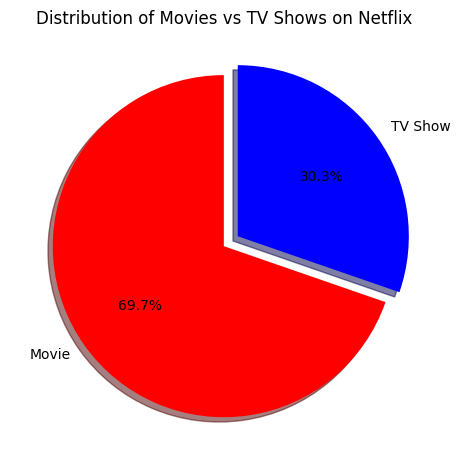

In [179]:
show_count = df['type'].value_counts()

colors = ['red', 'blue']
explode = [0, 0.1]

show_count.plot(kind='pie',colors=colors,autopct='%1.1f%%',explode=explode,shadow=True,startangle=90)

plt.title('Distribution of Movies vs TV Shows on Netflix')
plt.ylabel('')  
plt.tight_layout()
plt.savefig('kpi/movie_vs_tv_show_distribution.pdf')



## number of show relese per year

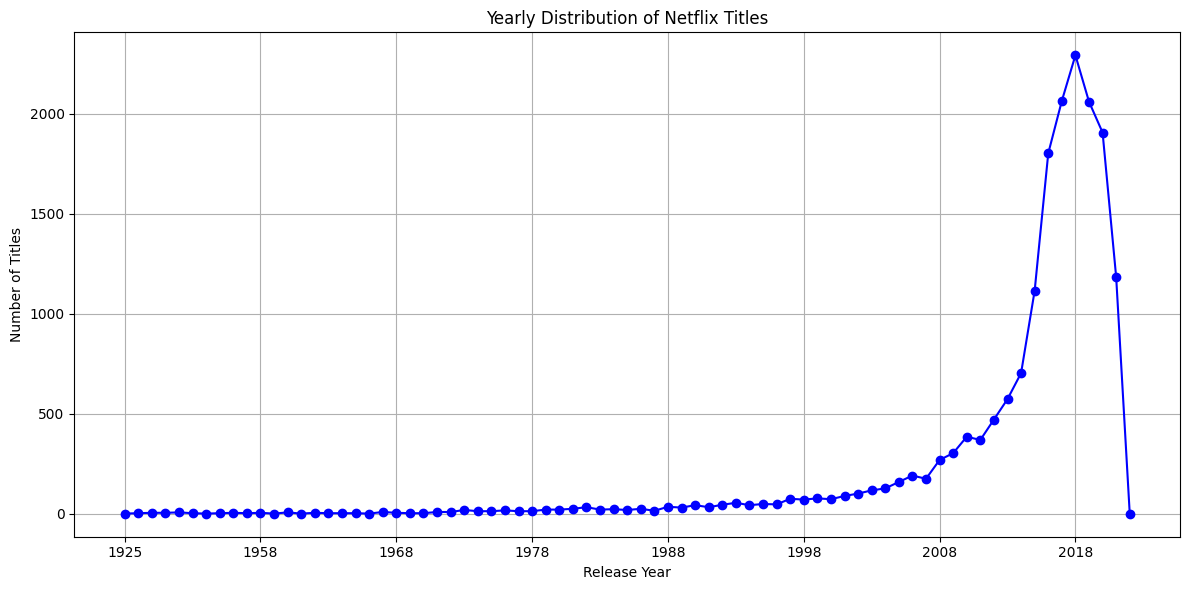

In [180]:
show_per_year = df.groupby('release_year')['title'].count()

fig, ax = plt.subplots(figsize=(12, 6))  # Set appropriate size

show_per_year.plot(kind='line', marker='o', ax=ax, color='blue')
plt.ylabel('Number of Titles')
plt.xlabel('Release Year')
plt.title('Yearly Distribution of Netflix Titles')
plt.grid(True)
plt.tight_layout()
plt.savefig('kpi/netflix_content_per_year.pdf')


## Top countries producing content on Netflix

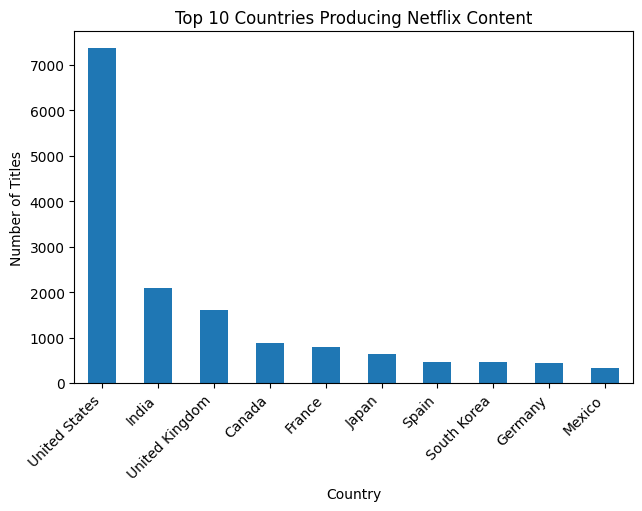

In [181]:
country_split = df['country'].str.split(',', expand=True)
all_countries = country_split.stack().str.strip().value_counts()
all_countries = all_countries.drop('Unknown', errors='ignore')
top_countries = all_countries.head(10)
top_countries.plot(kind='bar',color = '#1f77b4')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.title('Top 10 Countries Producing Netflix Content')
plt.savefig('kpi/top_10_countries_netflix.pdf')

## number of show per year

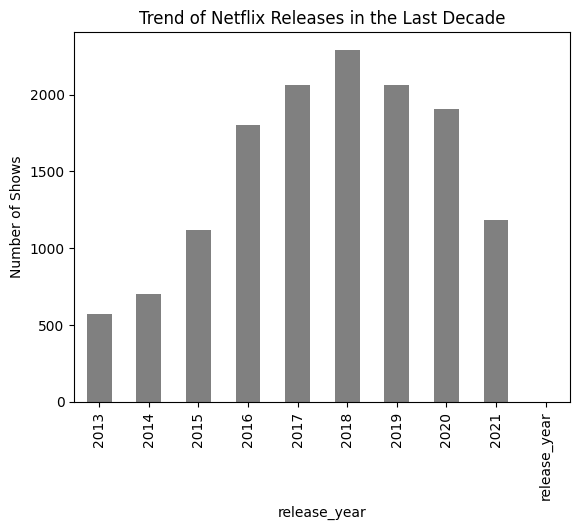

In [182]:
no = df.groupby('release_year')['title'].count()
no_of_show = no.tail(10)
no_of_show.plot(kind='bar',color = 'gray')
plt.ylabel('Number of Shows')
plt.title('Trend of Netflix Releases in the Last Decade')
plt.savefig('kpi/number of show per year.pdf')

## Top 10 Most Featured Directors on Netflix

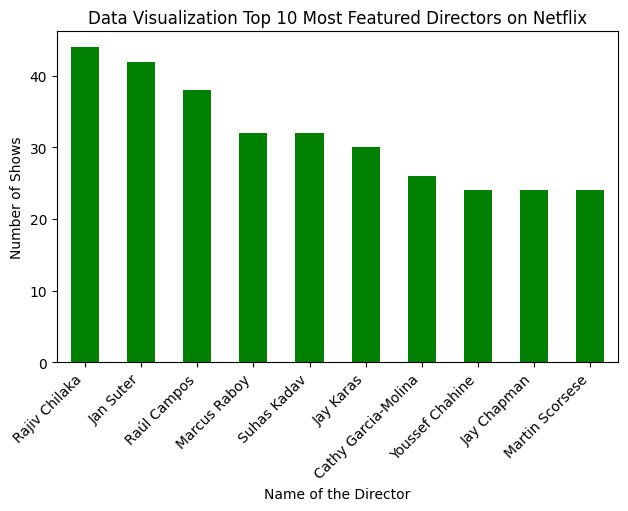

In [183]:
director_split = df['director'].str.split(',', expand=True)
all_directors = director_split.stack().str.strip().value_counts().drop('Unknown')
top_directors = all_directors.head(10)
top_directors.plot(kind='bar',color='green')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.xlabel('Name of the Director')
plt.ylabel('Number of Shows')
plt.title('Data Visualization Top 10 Most Featured Directors on Netflix')
plt.savefig('kpi/Top_Ten_Most_Frequent_Directors.pdf')

## All Visualization In One frame

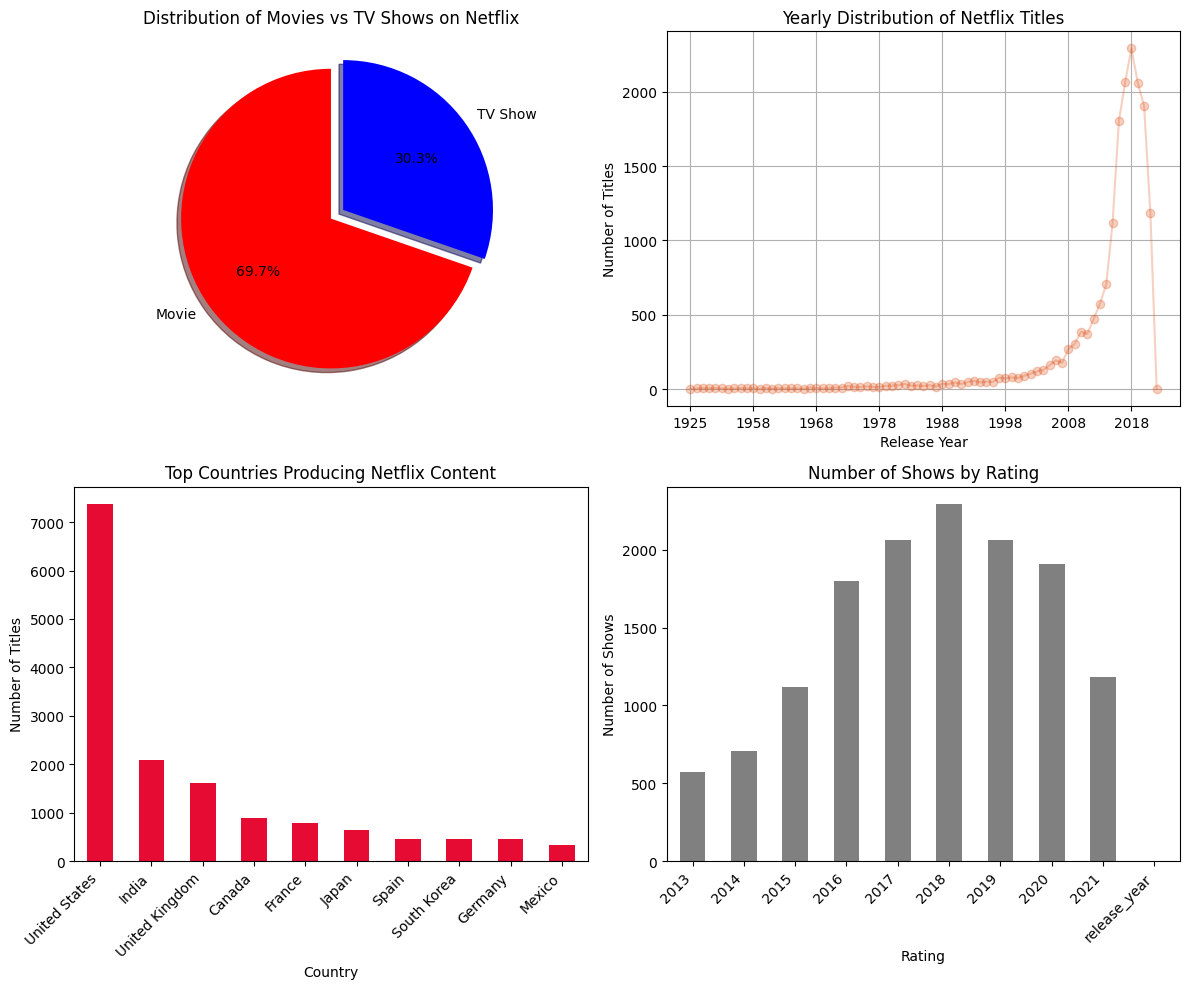

In [190]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

# 1. Pie Chart
plt.subplot(2, 2, 1)
show_count.plot(kind='pie', colors=colors, autopct='%1.1f%%', explode=explode, shadow=True, startangle=90)
plt.title('Distribution of Movies vs TV Shows on Netflix')
plt.ylabel('')

# 2. Line Chart - Content per Year
plt.subplot(2, 2, 2)
show_per_year = df.groupby('release_year')['title'].count()
show_per_year.plot(kind='line', marker='o', color="#DD4B1142")
plt.ylabel('Number of Titles')
plt.xlabel('Release Year')
plt.title('Yearly Distribution of Netflix Titles')
plt.grid(True)
plt.tight_layout()
plt.savefig('kpi/netflix_content_per_year.pdf')


# 3. Bar Chart - Top Countries
plt.subplot(2, 2, 3)
top_countries.plot(kind='bar', color="#e60b33")
plt.title('Top Countries Producing Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')

# 4. Bar Chart - Show Count by Rating (or any other category)
plt.subplot(2, 2, 4)
no_of_show.plot(kind='bar', color='gray')
plt.title('Number of Shows by Rating')
plt.ylabel('Number of Shows')
plt.xlabel('Rating')
plt.xticks(rotation=45, ha='right')

# Final layout adjustment
plt.tight_layout()
plt.savefig('kpi/all.pdf')
plt.show()


In [185]:
os.makedirs('clean', exist_ok=True)
df.to_csv('clean/netflix_titles_cleaned.csv', index=False)

In [186]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0
